## **Polynomial Regression**

### **Topic Roadmap**

 **1. Imports and Setup**

 **2. Dataset Preparation**

 **3. Baseline Linear Regression**

 **4. Polynomial Regression Implementation**

 **5. Overfitting Demonstration**

### **1. Imports and Setup**

Import essential libraries for data generation, preprocessing, and modeling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\bmh.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\classic.mplstyle: The text.hinting_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.
In d:\Anaconda3\Lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle: The text.kerning_factor rcParam was deprecated in Matplotlib 3.11 and will be removed in 3.13.


### **2. Dataset Preparation**

Generate a non-linear dataset using a quadratic equation and split it into training and testing sets.

In [2]:
# Generate non-linear data: y = 0.8x^2 + 0.9x + 2 + noise
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# Create training and testing splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

### **3. Baseline Linear Regression**

Train a standard linear model to demonstrate underfitting on non-linear data.

In [3]:
# Initialize and train the baseline model
baseline_lr = LinearRegression()
baseline_lr.fit(X_train, y_train)

# Evaluate baseline performance
y_pred_baseline = baseline_lr.predict(X_test)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f"Baseline Linear Regression R2 Score: {baseline_r2:.4f}")

Baseline Linear Regression R2 Score: 0.2262


### **4. Polynomial Regression Implementation**

Transform the input features to include polynomial terms (degree 2) to capture non-linear relationships. We use standard Linear Regression to fit the transformed data.

In [4]:
# Transform features to include degree 2 polynomial terms
poly_transformer = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_transformer.fit_transform(X_train)
X_test_poly = poly_transformer.transform(X_test)

# Train a linear model on the polynomial features
poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)

# Evaluate polynomial model performance
y_pred_poly = poly_lr.predict(X_test_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression (Degree 2) R2 Score: {poly_r2:.4f}")

Polynomial Regression (Degree 2) R2 Score: 0.8827


### **5. Overfitting Demonstration**

Use a machine learning pipeline to apply an excessively high-degree polynomial. 

This shows how large degrees lead to extreme overfitting. Scaling is mandatory here to prevent numerical instability.

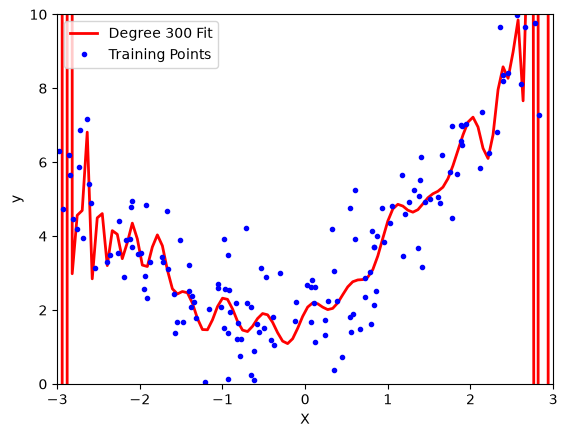

In [5]:
# Define a pipeline for high-degree polynomial regression
high_degree_model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=300, include_bias=False)),
    ("std_scaler", StandardScaler()),
    ("lin_reg", LinearRegression())
])

# Fit the highly complex model
high_degree_model.fit(X_train, y_train)

# Plot the overfitted curve against the training data
X_plot = np.linspace(-3, 3, 100).reshape(100, 1)
y_plot = high_degree_model.predict(X_plot)

plt.plot(X_plot, y_plot, 'r', label="Degree 300 Fit", linewidth=2)
plt.plot(X_train, y_train, "b.", label="Training Points")
plt.axis([-3, 3, 0, 10])
plt.xlabel("X")
plt.ylabel("y")
plt.legend(loc="upper left")
plt.show()

### **Key Revision Notes**

- **Polynomial Features:** Transforms the original input features into polynomial combinations (e.g., $X$ becomes $X, X^2, X^3$). This allows standard linear models to fit non-linear curves.
- **Degree Selection:**
  - **Low degree:** Fails to capture complex patterns (underfitting).
  - **Optimal degree:** Captures the underlying true relationship without modeling the noise.
  - **High degree:** Memorizes training noise and creates wild oscillations (overfitting).
- **Pipelines & Scaling:** You must apply feature scaling (like `StandardScaler`) before passing high-degree polynomial features into a model to prevent extreme value variations and numerical overflows.